# Задание 3

## Бинарная классификация сбалансированного и несбалансированного набора данных

### *Цель работы:* изучение принципов решения задачи классификации с использованием методов машинного обучения
*Основные задачи:*

• изучение инструментария Python для реализации алгоритмов бинарной
классификации;

• освоение метода логистической регрессии;

• изучение методов оценки корректности модели бинарной классификации;

Проанализируем датасет **blood**.  Набор данных содержит информацию о донорах и выполненных ими трансфузиях до марта 2007 г. включительно. Целью исследования является построение прогноза сдачи донором крови в марте 2007 г. Полученный результат позволяет оценить вероятность посещения донором центра сдачи крови в дальнейшем и относится к задачам бинарной классификации. В исследовании используется база данных доноров медицинского центра города Синьчжу на Тайване. Из базы данных медицинского центра случайным образом были выбраны 748 доноров для анализа.

**Атрибуты:**

• *Recency* – количество месяцев с момента последней сдачи крови донором;

• *Frequency* – общее количество трансфузий донора;

• *Monetary* – количество сданной донором крови в куб. см.;

• *Time* – количество месяцев с момента первого донорства;

• *Class* – целевая переменная прогноза трансфузии.

# 1. Импортируйте необходимые библиотеки

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# 2. Импортируйте набор данных из файла blood.сsv и поместите его в объект DataFrame

In [3]:
df = pd.read_csv("blood.csv")

# 3. Выведите данные

In [4]:
df.head()

,Recency,Frequency,Monetary,Time,Class
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


# 4. Проверить сбалансированность набора данных

Введем целевую переменную, целевые имена и частоту каждого уникального значения:

In [6]:
(unique, counts) = np.unique(df['Class'], return_counts=True)

print('Unique values of the target variable:', unique)
print('Counts of the target variable:', counts)

Unique values of the target variable: [0 1]
Counts of the target variable: [570 178]


Построим столбчатую диаграмму, чтобы увидеть целевую переменную: 

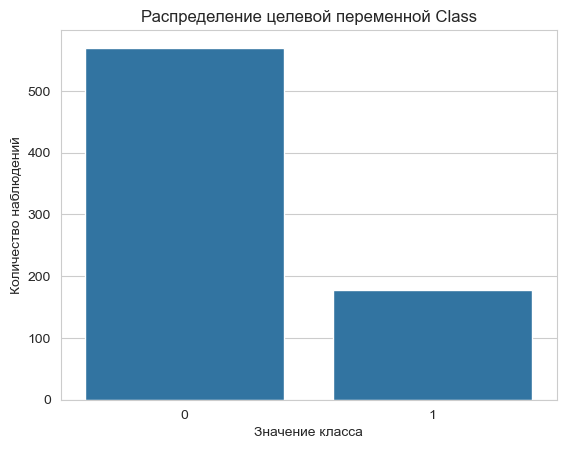

In [7]:
sns.set_style("whitegrid")
sns.countplot(df, x='Class')
plt.title('Распределение целевой переменной Class')
plt.xlabel('Значение класса')
plt.ylabel('Количество наблюдений')
plt.show()

Анализ диграммы показывает, что набор данных является несбалансированным 

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Recency    748 non-null    int64
 1   Frequency  748 non-null    int64
 2   Monetary   748 non-null    int64
 3   Time       748 non-null    int64
 4   Class      748 non-null    int64
dtypes: int64(5)
memory usage: 29.3 KB


In [10]:
print("Количество строк:", df.shape[0])
print("Количество столбцов:", df.shape[1])

Количество строк: 748
Количество столбцов: 5


In [11]:
df.describe()

,Recency,Frequency,Monetary,Time,Class
count,748.000000,748.000000,748.000000,748.000000,748.000000
mean,9.506684,5.514706,1378.676471,34.282086,0.237968
std,8.095396,5.839307,1459.826781,24.376714,0.426124
min,0.000000,1.000000,250.000000,2.000000,0.000000
25%,2.750000,2.000000,500.000000,16.000000,0.000000
50%,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,14.000000,7.000000,1750.000000,50.000000,0.000000
max,74.000000,50.000000,12500.000000,98.000000,1.000000


# 5. Проверим наличие пропущенных значений и выбросов

Проверим датасе на пропущенные значения:

In [12]:
print(df.isnull().sum())

Recency      0
Frequency    0
Monetary     0
Time         0
Class        0
dtype: int64


Нулевые значения в датасете отсутствуют. 

Далее проверим датасет на выбросы:

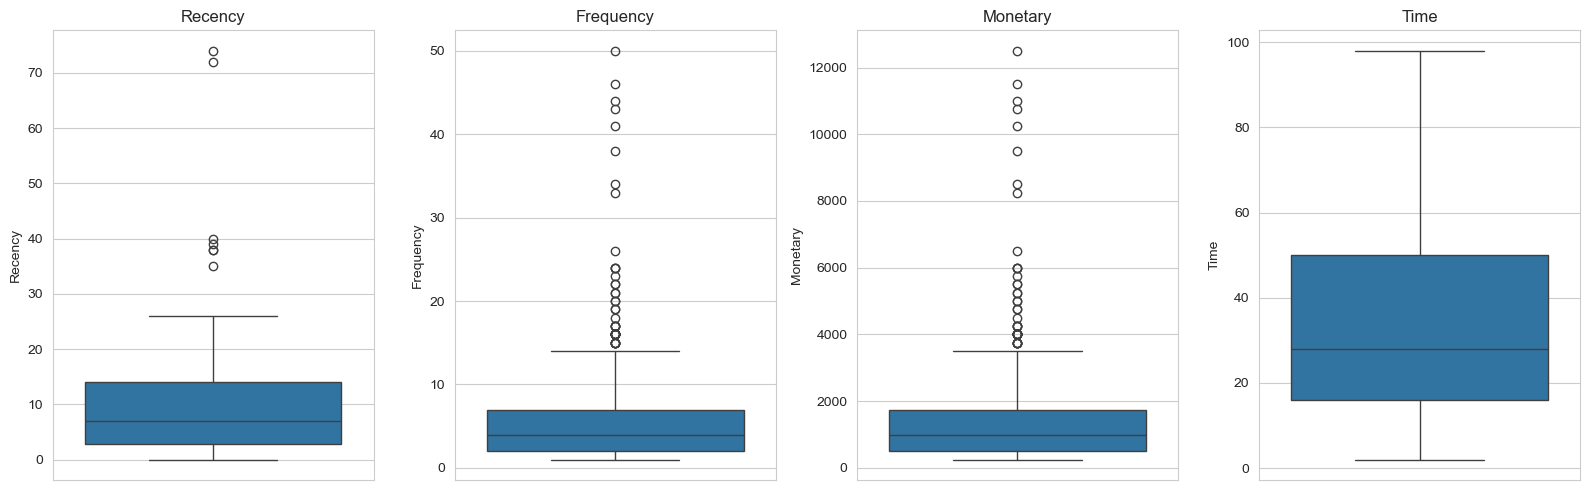

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

numeric_cols = ['Recency', 'Frequency', 'Monetary', 'Time']

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# 6. Исключаем невлияющие категориальные признаки

In [15]:
print(df['Recency'].nunique())
print(df['Frequency'].nunique())
print(df['Monetary'].nunique())
print(df['Time'].nunique())
print(df['Class'].nunique())

31
33
33
78
2


In [16]:
df.head(12)

,Recency,Frequency,Monetary,Time,Class
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0
5,4,4,1000,4,0
6,2,7,1750,14,1
7,1,12,3000,35,0
8,2,9,2250,22,1
9,5,46,11500,98,1


# 7. Разделяем данные на признаки и целевую переменную

In [17]:
y = df['Class']
X = df.drop('Class', axis = 1)
X

,Recency,Frequency,Monetary,Time
0,2,50,12500,98
1,0,13,3250,28
2,1,16,4000,35
3,2,20,5000,45
4,1,24,6000,77
...,...,...,...,...
743,23,2,500,38
744,21,2,500,52
745,23,3,750,62
746,39,1,250,39


# 8. Применяем операцию нормализации для численной устойчивости

In [19]:
from sklearn.preprocessing import StandardScaler
standardizer = StandardScaler()
X = standardizer.fit_transform(X)
X

array([[-0.92789873,  7.62334626,  7.62334626,  2.61563344],
       [-1.17511806,  1.28273826,  1.28273826, -0.2578809 ],
       [-1.0515084 ,  1.79684161,  1.79684161,  0.02947053],
       ...,
       [ 1.66790417, -0.43093957, -0.43093957,  1.13782607],
       [ 3.64565877, -0.77367514, -0.77367514,  0.19367135],
       [ 7.72477762, -0.77367514, -0.77367514,  1.54832812]])

# 9. Разделяем данные на тренировочный и тестовый наборы

75% данных для обучения и 25% - для тестирования

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=0)

# 10. Обучаем модель логистической регрессии

In [21]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

# 11. Делаем прогноз на основе данных тестирования

In [22]:
y_pred = model.predict(X_test)

# 12. Рассчитываем показатели точности, сравнив фактические и прогнозируемые значения

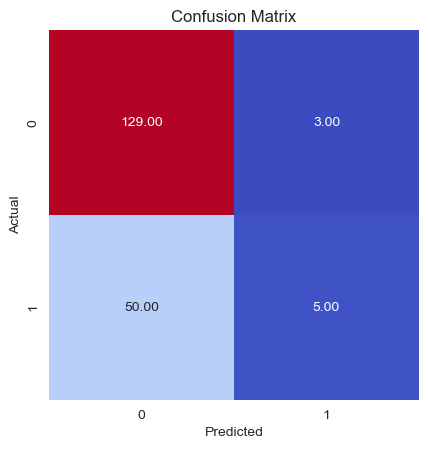

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, square=True, annot=True, fmt='.2f', cbar=False, cmap='coolwarm')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [26]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Точность (Precision): {precision:.2f}")
print(f"Полнота (Recall): {recall:.2f}")

Точность (Precision): 0.62
Полнота (Recall): 0.09


In [27]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print(f"F1-мера: {f1:.2f}")


F1-мера: 0.16


In [28]:
df.corr()

,Recency,Frequency,Monetary,Time,Class
Recency,1.000000,-0.182745,-0.182745,0.160618,-0.279869
Frequency,-0.182745,1.000000,1.000000,0.634940,0.218633
Monetary,-0.182745,1.000000,1.000000,0.634940,0.218633
Time,0.160618,0.634940,0.634940,1.000000,-0.035854
Class,-0.279869,0.218633,0.218633,-0.035854,1.000000


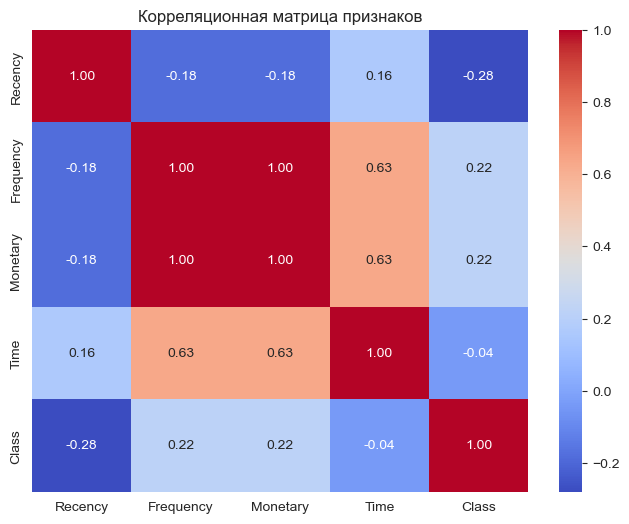

In [29]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица признаков')
plt.show()

# 13. Построение ROC-кривой

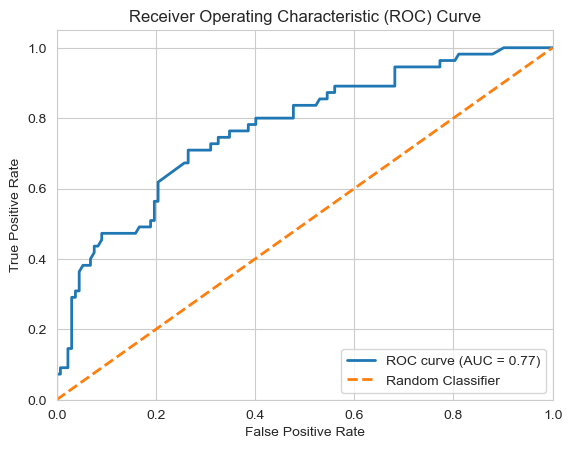

In [33]:
from sklearn.metrics import roc_curve, auc

y_score = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()